## Assignment Machine Learning
 _Authors: Ela, Emma, Florence, Jelle_ 

 _Date: 28-03-2026_

Importing packages 

In [1]:
import pandas as pd
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, ttest_ind 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from tempfile import mkdtemp
from shutil import rmtree

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, precision_recall_curve, roc_curve

Basics for all models

In [2]:
scores_dict = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

Load data 

In [3]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

Data description

In [4]:
print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')

print(f'The number of NaN values in the entire dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')
print(f'The percentage of samples with label 0 is thus {len(raw_data[raw_data["label"] == 0])/len(raw_data.index)*100:.2f}%', 
      f'and the percentage with label 1 {len(raw_data[raw_data["label"] == 1])/len(raw_data.index)*100:.2f}%')

The number of samples: 827
The number of columns: 9001
The number of NaN values in the entire dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146
The percentage of samples with label 0 is thus 82.35% and the percentage with label 1 17.65%


Splitting the data in a training and test set

In [5]:
X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=4, stratify=Y)

Preprocessing of data

In [6]:
class VarianceFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.columns_to_drop_ = [col for col in X.columns if np.var(X[col]) < self.threshold]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.columns_to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class TTestFilter(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=0.05):
        self.alpha = alpha

    def fit(self, X, y):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]

        self.columns_to_drop_ = []
        threshold = self.alpha / X.shape[1]  # Bonferroni

        for col in X.columns:
            group0 = X.loc[y == 0, col]
            group1 = X.loc[y == 1, col]
            _, p_value = ttest_ind(group0, group1, nan_policy="omit")

            if p_value > threshold:
                self.columns_to_drop_.append(col)

        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


pipeline = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler())
    ])

pipeline.fit(x_train, y_train)
x_train_preprocessed = pipeline.transform(x_train)
x_test_preprocessed = pipeline.transform(x_test)

#amount of features after preprocessing 
x_train_var = pipeline.named_steps["variance"].transform(x_train)
x_train_corr = pipeline.named_steps["correlation"].transform(x_train_var)
x_train_t = pipeline.named_steps["ttest"].transform(x_train_corr)

print(f"Start amount features: {x_train.shape[1]}")
print(f"After the variance filter: {x_train_var.shape[1]}")
print(f"After the correlation filter: {x_train_corr.shape[1]}")
print(f"After the t-test filter: {x_train_t.shape[1]}")

Start amount features: 9000
After the variance filter: 9000
After the correlation filter: 4068
After the t-test filter: 47


Function for the evaluation metrics on test set (Precision, Recall, F1, PR-AUC, ROC-AUC and plot of PR-AUC and ROC-AUC)

In [7]:
def evaluate_model_on_test(clf, x_test, y_test, name="Model"):
    '''
        Call function as follows:
        - scores_dict.update(evaluate_model_on_test(...))

        Naming convention for models:
        - LR        -->     Logistic Regression
        - RF        -->     Random Forest
        - SVM       -->     Support Vector Machine
        - XGB       -->     XGBoost
        - PLS-DA    -->     Partial Least-Squares Discriminant Analysis
        - NN        -->     Neural Network
        
    '''
    y_pred = clf.predict(x_test)
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(x_test)[:, 1]
    else:
        y_score = clf.decision_function(x_test)

    # Calculate metrics
    precision = precision_score(y_test, y_pred, zero_division=1)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_score)
    auc_roc = roc_auc_score(y_test, y_score)

    # Print results
    print(f"--- Evaluation: {name} ---")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-Score:   {f1:.4f}")
    print(f"AUC-PR:     {auc_pr:.4f}")
    print(f"ROC-AUC:    {auc_roc:.4f}")
    print("-" * 30)

    return {name: y_score} #for final plots with all models


Logistic regression model

In [16]:
pipeline_lr = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),  #data scaling is important for model convergence with the saga solver
    ('classifier', LogisticRegression(
        solver='saga',
        random_state=4,
        max_iter=5000  # important for convergence
    ))
])

param_dist = {
    'classifier__C': loguniform(1e-3, 10),  
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    cv=kf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=4
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)

c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters found:
 {'classifier__C': np.float64(0.05553753341120423), 'classifier__class_weight': None, 'classifier__penalty': 'l1'}
Best score: 0.5352283241363913


In [17]:
param_grid_lr = {
    'classifier__C': [0.01, 0.05, 0.1, 0.15],
    'classifier__penalty': ['l1'],  
    'classifier__class_weight': [None],  
}

grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_lr.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_lr.best_params_)
print("Best score:", grid_search_lr.best_score_)

c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters found:
 {'classifier__C': 0.05, 'classifier__class_weight': None, 'classifier__penalty': 'l1'}
Best score: 0.5366527414450639


In [18]:
lr_model = grid_search_lr.best_estimator_ 

scores_dict.update(evaluate_model_on_test(lr_model, x_test, y_test, name="LR"))

--- Evaluation: LR ---
Precision:  0.6667
Recall:     0.1379
F1-Score:   0.2286
AUC-PR:     0.4066
ROC-AUC:    0.7063
------------------------------


Random forest model

In [19]:
pipeline_rf = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler()),
    ("rf", RandomForestClassifier(random_state=4, class_weight="balanced"))
])

param_dist = {
    "rf__n_estimators": randint(100, 600),
    "rf__max_depth": randint(1, 50),
    "rf__min_samples_split": randint(2, 20),
    "rf__min_samples_leaf": randint(1, 10),
    "rf__max_features": ["sqrt", "log2", None],
    "rf__bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring="average_precision",
    cv=kf,
    n_jobs=-1,
    random_state=4,
    return_train_score=True
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters found:
 {'rf__bootstrap': True, 'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 7, 'rf__min_samples_split': 10, 'rf__n_estimators': 546}
Best score: 0.5671855638558977


In [20]:
param_grid_rf = {
    "rf__n_estimators": [200, 225, 250],
    "rf__max_depth": [15, 20, 25],
    "rf__min_samples_split": [6, 8, 10],
    "rf__min_samples_leaf": [6, 8, 10],
    "rf__max_features": ["sqrt"],
    "rf__bootstrap": [True]
}

grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_rf.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_rf.best_params_)
print('Best score:', grid_search_rf.best_score_)

Best parameters found:
 {'rf__bootstrap': True, 'rf__max_depth': 15, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 8, 'rf__min_samples_split': 6, 'rf__n_estimators': 250}
Best score: 0.5681168441186365


In [21]:
rf_model = grid_search_rf.best_estimator_ 

scores_dict.update(evaluate_model_on_test(rf_model, x_test, y_test, name="RF"))

--- Evaluation: RF ---
Precision:  0.3913
Recall:     0.3103
F1-Score:   0.3462
AUC-PR:     0.4962
ROC-AUC:    0.7805
------------------------------


Support Vector Machine (SVM)

In [22]:
svm_pipeline = Pipeline([
    ('variance', VarianceFilter(threshold=0.01)),
    ('correlation', CorrelationFilter(threshold=0.95)),
    ('ttest', TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=4))
])

param_distributions = [
    {
        'svm__kernel': ['rbf', 'sigmoid'],
        'svm__C': loguniform(1e-2, 100),
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-2, 10),
        'svm__degree': randint(2, 5)
    },
    {
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-2, 100)
    }
]

random_search_svm = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_distributions,
    n_iter=50, 
    scoring='average_precision', 
    cv=kf,
    n_jobs=-1 
)

random_search_svm.fit(x_train, y_train)

print('Best parameters found:\n', random_search_svm.best_params_)
print("Best score:", random_search_svm.best_score_)

c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found:
 {'svm__C': np.float64(0.07012547868719585), 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
Best score: 0.5270335536208666


In [ ]:
param_grid_svm = {
    "svm__kernel": ["sigmoid"],
    "svm__gamma": [0.01, 'auto'],
    "svm__C": [0.05, 0.07, 0.1]
}

grid_search_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_svm.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_svm.best_params_)
print('Best score:', grid_search_svm.best_score_)

Best parameters found:
 {'svm__C': 0.05, 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
Best score: 0.5437970594774348


In [25]:
svm_model = grid_search_svm.best_estimator_ 

scores_dict.update(evaluate_model_on_test(svm_model, x_test, y_test, name="SVM"))

--- Evaluation: SVM ---
Precision:  0.3051
Recall:     0.6207
F1-Score:   0.4091
AUC-PR:     0.4567
ROC-AUC:    0.7148
------------------------------


XGBoost (XGB)

In [26]:
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum() # because of imbalanced dataset, give more weight to the minority class (label 1) in XGBoost

xgb_pipeline = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler()),
    ("xgb", XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight_val,
        random_state=4,
        eval_metric='logloss',
        tree_method='hist'
    ))
])

param_distributions = {
    'xgb__learning_rate': loguniform(1e-2,0.5), 
    'xgb__max_depth': randint(2,5),             
    'xgb__n_estimators': randint(100,500),  
    'xgb__subsample': loguniform(0.5, 1.0),     
    'xgb__colsample_bytree': loguniform(0.5, 0.9),   
    'xgb__reg_alpha': loguniform(0.1, 5), #L1 regularization
    'xgb__reg_lambda': randint(1,50) #L2 regularization
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,          
    scoring='average_precision', 
    cv=kf,
    random_state=4,
    n_jobs=-1 
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters found:
 {'xgb__colsample_bytree': np.float64(0.6074488991764556), 'xgb__learning_rate': np.float64(0.09376626326183432), 'xgb__max_depth': 2, 'xgb__n_estimators': 154, 'xgb__reg_alpha': np.float64(1.3723888866289522), 'xgb__reg_lambda': 33, 'xgb__subsample': np.float64(0.5157156850230444)}
Best score: 0.5804447115843748


In [ ]:
param_grid_xgb = {
    'xgb__learning_rate': [0.05, 0.1, 0.15], 
    'xgb__max_depth': [1, 2, 3],             
    'xgb__n_estimators': [100, 150, 200],  
    'xgb__subsample': [0.4, 0.5, 0.6],     
    'xgb__colsample_bytree': [0.5, 0.6, 0.7],   
    'xgb__reg_alpha': [1, 1.5, 2], #L1 regularization
    'xgb__reg_lambda': [25, 30, 35] #L2 regularization
}

grid_search_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_xgb.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_xgb.best_params_)
print('Best score:', grid_search_xgb.best_score_)

In [ ]:
xgb_model = grid_search_xgb.best_estimator_ 

scores_dict.update(evaluate_model_on_test(xgb_model, x_test, y_test, name="XGB"))

Partial Least-Squares Discriminant Analysis (PLS-DA)

In [ ]:
class PLSDA(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.model = PLSRegression(n_components=n_components)

    def fit(self, X, y):
        y = np.asarray(y).ravel()
        self.model = PLSRegression(n_components=self.n_components)
        self.model.fit(X, y)
        return self

    def predict_proba(self, X):
        y_cont = self.model.predict(X).ravel()
        y_cont = np.clip(y_cont, 0, 1)
        return np.vstack([1 - y_cont, y_cont]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

In [ ]:
pipeline_pls_da = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),
    ('classifier', PLSDA()),
    ])

param_dist = {
    'classifier__n_components': randint(1, 47),
}

random_search = RandomizedSearchCV(
    pipeline_pls_da,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    cv=kf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=4
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)


/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/flo

Best parameters found:
 {'classifier__C': np.float64(0.037249864670657974), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'pls__n_components': 3}
Best score: 0.5402856481006166


In [ ]:
param_grid_pls_da = {
    'classifier__n_components': [2, 3, 5],
    }

grid_search_pls_da = GridSearchCV(pipeline_pls_da, param_grid_pls_da, cv=kf, scoring="average_precision", n_jobs=-1)
grid_search_pls_da.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_pls_da.best_params_)
print("Beste score:", grid_search_pls_da.best_score_)

/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/flo

Best parameters found:
 {'classifier__C': 0.05, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'pls__n_components': 3}
Beste score: 0.537312417579171


/Users/florencehietink/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
pls_da_model = grid_search_pls_da.best_estimator_ 

scores_dict.update(evaluate_model_on_test(pls_da_model, x_test, y_test, name="PLS-DA"))

--- Evaluation: PLS-DA ---
Precision:  0.3220
Recall:     0.6552
F1-Score:   0.4318
AUC-PR:     0.3773
ROC-AUC:    0.7100
------------------------------


Feed-forward neural network

In [ ]:

pipeline_NN = Pipeline(steps=[
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),
    ('classifier', MLPClassifier(early_stopping=True, random_state=4)) 
])

param_grid_NN = {
    'classifier__hidden_layer_sizes': [(32, 16, 8), (64,), (128, 64)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd', 'lbfgs'],  
    'classifier__learning_rate_init': loguniform(1e-4, 1e-2),
    'classifier__alpha': loguniform(1e-5, 1e-2),
    'classifier__max_iter': randint(150, 500),
}

random_search_NN = RandomizedSearchCV(
    pipeline_NN,
    param_distributions=param_grid_NN,
    n_iter=50,  # number of random combinations
    cv=kf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=4
)

random_search_NN.fit(x_train, y_train)

print('Best parameters found:\n', random_search_NN.best_params_)
print("Best score:", random_search_NN.best_score_)

KeyboardInterrupt: 

In [ ]:
param_grid_NN = {
    'classifier__hidden_layer_sizes': [(65,), (128, 64)],
    'classifier__activation': ['tanh', 'relu'],
    'classifier__solver': ['adam','lbfgs'],
    'classifier__learning_rate_init': [1e-2, 1e-3, 5e-3],
    'classifier__alpha': [1e-4, 5e-5, 5e-4],
    'classifier__learning_rate': ['constant'],
    'classifier__max_iter': [250, 275, 300]
}

grid_search_NN = GridSearchCV(pipeline_NN, param_grid_NN, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_NN.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_NN.best_params_)
print("Best score:", grid_search_NN.best_score_)

c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\emma_\miniconda3\envs\techn

Best parameters found:
 {'classifier__activation': 'tanh', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__learning_rate': 'constant', 'classifier__learning_rate_init': 0.005, 'classifier__max_iter': 250, 'classifier__solver': 'adam'}
Best score: 0.5077678197067753


In [ ]:
NN_model = grid_search_NN.best_estimator_ 

scores_dict.update(evaluate_model_on_test(NN_model, x_test, y_test, name="NN"))

--- Evaluation: NN ---
Precision:  0.5238
Recall:     0.3793
F1-Score:   0.4400
AUC-PR:     0.4216
ROC-AUC:    0.7402
------------------------------


Precision-recall curve of all models

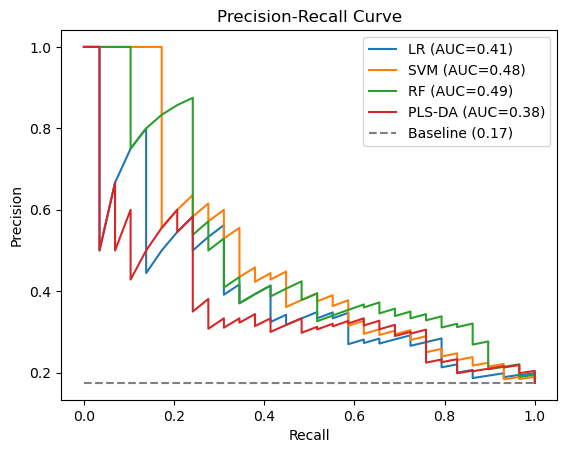

In [ ]:
def plot_pr_auc(labels, scores_dict):
    y_true = labels.values.ravel()
    baseline = np.mean(y_true)

    plt.figure()

    for name, probs in scores_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, probs)
        auc = average_precision_score(y_true, probs)

        plt.plot(recall, precision, label=f'{name} (AUC={auc:.2f})')

    plt.hlines(baseline, 0, 1, colors='grey', linestyles='dashed',
               label=f'Baseline ({baseline:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

plot_pr_auc(y_test, scores_dict)

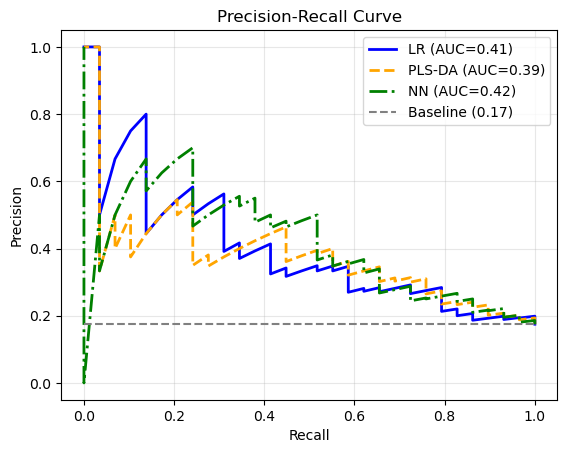

In [ ]:
def plot_pr_auc(labels, scores_dict):
    y_true = labels.values.ravel()
    baseline = np.mean(y_true)

    plt.figure()

    linestyles = ['-', '--', '-.', ':']
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

    for i, (name, probs) in enumerate(scores_dict.items()):
        precision, recall, _ = precision_recall_curve(y_true, probs)
        auc = average_precision_score(y_true, probs)

        plt.plot(
            recall,
            precision,
            linestyle=linestyles[i % len(linestyles)],
            color=colors[i % len(colors)],
            linewidth=2,
            label=f'{name} (AUC={auc:.2f})'
        )

    plt.hlines(
        baseline, 0, 1,
        colors='grey',
        linestyles='dashed',
        linewidth=1.5,
        label=f'Baseline ({baseline:.2f})'
    )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_pr_auc(y_test, scores_dict)

Receiver operating characteristic curve for all models 

In [ ]:
def plot_roc_auc(labels, scores_dict):
    y_true = labels.values.ravel()

    plt.figure()

    linestyles = ['-', '--', '-.', ':']
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

    for i, (name, probs) in enumerate(scores_dict.items()):
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc = roc_auc_score(y_true, probs)

        plt.plot(
            fpr,
            tpr,
            linestyle=linestyles[i % len(linestyles)],
            color=colors[i % len(colors)],
            linewidth=2,
            label=f'{name} (AUC={auc:.2f})'
        )

    plt.plot(
        [0, 1], [0, 1],
        color='grey',
        linestyle='dashed',
        linewidth=1.5,
        label='Random (AUC=0.50)' #baseline for a random classifier
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_auc(y_test, scores_dict)